### 연결 자료구조(Linked Data Structure)
#### 자료의 논리적인 순서와 물리적인 순서가 일치하지 않는 자료구조
* 각 원소에 저장되어 있는 다음 원소의 주소에 의해 순서가 연결되는 방식
* 물리적인 순서를 맞추기 위한 오버헤드가 발생하지 않음 
* 여러 개의 작은 공간을 연결하여 하나의 전체 자료구조를 표현
* 크기 변경이 유연하고 더 효율적으로 메모리를 사용
#### 노드
##### 연결 자료구조에서 하나의 원소를 표현하기 위한 단위 구조
* <원소, 주소>의 구조

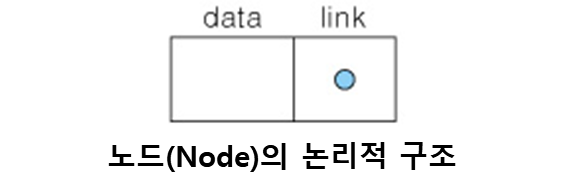

#### 단순 연결 리스트
#####   노드가 하나의 링크 필드에 의해서 다음 노드와 연결되는 구조를 가진 연결 리스트

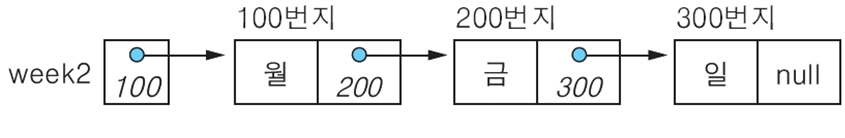

In [75]:
class ListNode:
	def __init__(self, newItem, nextNode:'ListNode'):
		self.item = newItem
		self.next = nextNode

In [76]:
class LinkedListBasic:
	def __init__(self):
		self.__head = ListNode('dummy', None)
		self.__numItems = 0

	# 연결 리스트에 원소 삽입하기(더미 헤드를 두는 버전)
	def insert(self, i:int, newItem):
		if i >= 0 and i <= self.__numItems:
			prev = self.__getNode(i - 1)
			newNode = ListNode(newItem, prev.next)
			prev.next = newNode
			self.__numItems += 1
		else:
			print("index", i, ": out of bound in insert()") # 필요 시 에러 처리
 
	def append(self, newItem):
		prev = self.__getNode(self.__numItems - 1)
		newNode = ListNode(newItem, prev.next)
		prev.next = newNode
		self.__numItems += 1

	# 연결 리스트의 원소 삭제하기
	def pop(self, i:int):   # i번 노드 삭제
		if (i >= 0 and i <= self.__numItems-1):
			prev = self.__getNode(i - 1)
			curr = prev.next
			prev.next = curr.next
			retItem = curr.item
			self.__numItems -= 1
			return retItem
		else:
			return None
	
	# 연결 리스트의 원소 x 삭제하기 (더미 헤드를 두는 버전)
	def remove(self, x):
		(prev, curr) = self.__findNode(x)
		if curr != None:
			prev.next = curr.next
			self.__numItems -= 1
			return x
		else:
			return None

	# 연결 리스트의 i번 원소 읽기
	def get(self, i:int):
		if self.isEmpty():
			return None
		if (i >= 0 and i <= self.__numItems - 1):
			return self.__getNode(i).item
		else:
			return None
 
	# x가 연결 리스트의 몇 번 원소인지 조회
	def index(self, x) -> int:
		curr = self.__head.next	 # 0번 노드:  더미 헤드 다음 노드
		for index in range(self.__numItems):
			if curr.item == x:
				return index
			else:
				curr = curr.next
		return -2 # 안 쓰는 인덱스

	# 기타 기능
	def isEmpty(self) -> bool:
		return self.__numItems == 0

	def size(self) -> int:
		return self.__numItems

	def clear(self):
		self.__head = ListNode("dummy", None)
		self.__numItems = 0

	def count(self, x) -> int:
		cnt = 0
		curr = self.__head.next  # 0번 노드
		while curr != None:
			if curr.item == x:
					cnt += 1
			curr = curr.next
		return cnt

	def extend(self, a): # 여기서 a는 self와 같은 타입의 리스트
		for index in range(a.size()):
			self.append(a.get(index))
 
	def copy(self):
		a = LinkedListBasic()
		for index in range(self.__numItems):
			a.append(self.get(index))
		return a

	def reverse(self):
		a = LinkedListBasic()
		for index in range(self.__numItems):
			a.insert(0, self.get(index))
		self.clear()
		for index in range(a.size()):
			self.append(a.get(index))

	def sort(self) -> None:
		a = []
		for index in range(self.__numItems):
			a.append(self.get(index))
		a.sort()
		self.clear()
		for index in range(len(a)):
			self.append(a[index])
 
	def __findNode(self, x) -> (ListNode, ListNode): # type: ignore
		prev = self.__head  # 더미 헤드
		curr = prev.next    # 0번 노드
		while curr != None:
			if curr.item == x:
				return (prev, curr)
			else:
				prev = curr; curr = curr.next
		return (None, None)

	# 연결 리스트의 i번 노드 조회
	def __getNode(self, i:int) -> ListNode:
		curr = self.__head # 더미 헤드, index: -1
		for index in range(i+1):
			curr = curr.next
		return curr
	
 	# 연결 리스트 전체 출력
	def printList(self):
		curr = self.__head.next # 0번 노드: 더미 헤드 다음 노드
		while curr != None:
			print(curr.item, end = ' ')
			curr = curr.next
		print()

In [81]:
week = LinkedListBasic()
week.append('월'); week.append('화'); week.append('목'); week.append('금'); 
week.printList()
week.insert(2, '수')
week.printList()
print(week.get(2))
week.printList()
print(week.pop(0))
week.printList()
week.append('금');
week.printList()
print(week.count('금'));
week.remove('금')
week.printList()
print(week)

월 화 목 금 
월 화 수 목 금 
수
월 화 수 목 금 
월
화 수 목 금 
화 수 목 금 금 
2
화 수 목 금 


In [78]:
class Contact:
	def __init__(self, item, nextNode:'Contact'):
		self.item = item
		self.next = nextNode

In [79]:
class ContactListBasic:
    def __init__(self):
        self.__head = Contact('dummy', None)
        self.__numItems = 0

    # 연결 리스트에 원소 삽입하기(더미 헤드를 두는 버전)
    def insert(self, i:int, newItem):
        if i >= 0 and i <= self.__numItems:
            prev = self.__getNode(i - 1)
            newNode = Contact(newItem, prev.next)
            prev.next = newNode
            self.__numItems += 1
        else:
            print("index", i, ": out of bound in insert()") # 필요 시 에러 처리
 
    def append(self, newItem):
        prev = self.__getNode(self.__numItems - 1)
        newNode = ListNode(newItem, prev.next)
        prev.next = newNode
        self.__numItems += 1

    # 연결 리스트의 원소 삭제하기
    def pop(self, i:int):   # i번 노드 삭제
        if (i >= 0 and i <= self.__numItems-1):
            prev = self.__getNode(i - 1)
            curr = prev.next
            prev.next = curr.next
            retItem = curr.item
            self.__numItems -= 1
            return retItem
        else:
            return None
	
	# 연결 리스트의 원소 x 삭제하기 (더미 헤드를 두는 버전)
    def remove(self, x):
        (prev, curr) = self.__findNode(x)
        if curr != None:
            prev.next = curr.next
            self.__numItems -= 1
            return x
        else:
            return None

    # 연결 리스트의 i번 원소 읽기
    def get(self, i:int):
        if self.isEmpty():
            return None
        if (i >= 0 and i <= self.__numItems - 1):
            return self.__getNode(i).item
        else:
            return None

    # x가 연결 리스트의 몇 번 원소인지 조회
    def index(self, x) -> int:
        curr = self.__head.next	 # 0번 노드:  더미 헤드 다음 노드
        for index in range(self.__numItems):
            if curr.item == x:
                return index
            else:
                curr = curr.next
        return -2 # 안 쓰는 인덱스

    # 기타 기능
    def isEmpty(self) -> bool:
        return self.__numItems == 0

    def size(self) -> int:
        return self.__numItems

    def clear(self):
        self.__head = Contact("dummy", None)
        self.__numItems = 0
        
    # 연결 리스트의 i번 노드 조회
    def __getNode(self, i:int) -> ListNode:
        curr = self.__head # 더미 헤드, index: -1
        for index in range(i+1):
            curr = curr.next
        return curr

    def printList(self):
        curr = self.__head.next # 0번 노드: 더미 헤드 다음 노드
        while curr != None:
            print(curr.item, end = ' ')
            curr = curr.next
        print()

In [ ]:
contactList = ContactListBasic()
contactList.append(['홍길동', '010-111-1111','서울'])
contactList.append(['이순신', '010-222-2222','부산'])
contactList.append(['임꺽정', '010-333-3333','대구'])
contactList.printList()
contactList.pop(1)
contactList.printList()